In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhilroxtomar/brain-tumor-segmentation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation


In [2]:
import os
import pickle

import torch
from PIL import Image


def check_path_exists(folder_path, filename):
    path = os.path.join(folder_path, filename)
    if not os.path.exists(path):
        raise ValueError(f"{path} does not exist")
    return True


def get_sub_folders_names(folder_path):
    sub_folders_name = [
        class_name
        for class_name in os.listdir(folder_path)
        if os.path.isdir(os.path.join(folder_path, class_name))
    ]
    return sub_folders_name


def save_pickle(folder_path, obj, filename):
    filepath = os.path.join(folder_path, filename)
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)


def load_pickle(folder_path, filename):
    filepath = os.path.join(folder_path, filename)
    with open(filepath, "rb") as f:
        obj = pickle.load(f)
    return obj


def lower_data(df):
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].apply(
                lambda x: x.lower() if isinstance(x, str) else x
            )


def drop_columns(X, col_drop):
    col_drop = list(col_drop.keys())
    if col_drop:
        X.drop(columns=col_drop, inplace=True, errors="ignore")


def is_valid_image(image_path):
    valid_extension = (".jpg", ".png", ".jpeg")

    if not os.path.isfile(image_path):
        return False
    if image_path.endswith(valid_extension):
        try:
            with Image.open(image_path) as img:
                img.verify()
            return True
        except Exception:
            return False
    return False


def collect_function(batch):
    images = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    images_stack = torch.stack(images, dim=0)
    if labels[0] is None:
        return images_stack
    labels = torch.tensor(labels, dtype=torch.long)
    return images_stack, labels

def collect_function_segmentation(batch):
    images = [item[0] for item in batch]
    masks = [item[1] for item in batch]
    images_stack = torch.stack(images, dim=0)
    if masks[0] is None:
        return images_stack
    masks_stack = torch.stack([mask for mask in masks], dim=0)
    return images_stack, masks_stack


# Image Dataset

In [3]:
import random

import numpy as np
from PIL import Image
from PIL import ImageEnhance
from torch.utils.data import Dataset


class ImageDataset(Dataset):
    def __init__(
        self,
        image_paths,
        labels=None,
        image_size=(224, 224),
        augment=True,
        augmentation_probability=0.5,
        horizontal_flip=True,
        vertical_flip=True,
        rotation=True,
        rotation_angle=30,
        brightness=True,
        brightness_factors=(0.8, 1.2),
        contrast=True,
        contrast_factors=(0.8, 1.2),
    ):
        self.image_paths = image_paths
        self.labels = labels
        self.image_size = image_size
        self.augment = augment
        self.horizontal_flip = horizontal_flip
        self.vertical_flip = vertical_flip
        self.augmentation_probability = augmentation_probability
        self.rotation = rotation
        self.rotation_angle = rotation_angle
        self.brightness = brightness
        self.brightness_factors = brightness_factors
        self.contrast = contrast
        self.contrast_factors = contrast_factors

    def __len__(self):
        return len(self.image_paths)

    

    def random_brightness(self, img):
        if self.brightness and random.random() < self.augmentation_probability:
            random_factor = random.uniform(*self.brightness_factors)
            return ImageEnhance.Brightness(img).enhance(random_factor)
        return img

    def random_contrast(self, img):
        if self.contrast and random.random() < self.augmentation_probability:
            random_factor = random.uniform(*self.contrast_factors)
            return ImageEnhance.Contrast(img).enhance(random_factor)
        return img



    


In [4]:
import random

import numpy as np
import torch
from PIL import Image


class SegmentationImageDataset(ImageDataset):
    def __init__(
        self,
        image_paths,
        masks=None,
        image_size=(224, 224),
        binary_mask_threshold=128,
        augment=True,
        augmentation_probability=0.5,
        horizontal_flip=True,
        vertical_flip=True,
        rotation=True,
        rotation_angle=30,
        brightness=True,
        brightness_factors=(0.8, 1.2),
        contrast=True,
        contrast_factors=(0.8, 1.2),
    ):
        super().__init__(
            image_paths,
            masks,
            image_size,
            augment,
            augmentation_probability,
            horizontal_flip,
            vertical_flip,
            rotation,
            rotation_angle,
            brightness,
            brightness_factors,
            contrast,
            contrast_factors,
        )
        self.binary_mask_threshold=binary_mask_threshold
    

    def load_image_masks(self, index):
        path = self.image_paths[index]
        img = Image.open(path).convert("RGB")
        img = img.resize(self.image_size,resample=Image.BILINEAR)
        mask = None
        if self.labels is not None:
            mask_path = self.labels[index]
            mask = Image.open(mask_path).convert("L")
            mask = mask.resize(self.image_size, resample=Image.NEAREST)

        if self.augment:
            img, mask = self.augmentation(img, mask)
        img_array = np.array(img, dtype=np.float32) / 255.0
        img_transpose = np.transpose(img_array, (2, 0, 1))
        img_tensor = torch.tensor(img_transpose, dtype=torch.float32)
        mask_tensor = None
        if mask is not None:
            mask_array = np.array(mask, dtype=np.float32)
            mask_array = (mask_array >= self.binary_mask_threshold).astype(np.float32)
            mask_tensor = torch.tensor(mask_array, dtype=torch.float32).unsqueeze(0)
        return img_tensor, mask_tensor

    def random_horizontal_flip(self, img, mask):
        transposed_img = img
        transposed_mask = mask
        if self.horizontal_flip and random.random() < self.augmentation_probability:
            transposed_img = img.transpose(Image.FLIP_LEFT_RIGHT)
            if mask is not None:
                transposed_mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
        return transposed_img, transposed_mask

    def random_vertical_flip(self, img, mask):
        transposed_img = img
        transposed_mask = mask
        if self.vertical_flip and random.random() < self.augmentation_probability:
            transposed_img = img.transpose(Image.FLIP_TOP_BOTTOM)
            if mask is not None:
                transposed_mask = mask.transpose(Image.FLIP_TOP_BOTTOM)
        return transposed_img, transposed_mask

    def random_rotation(self, img, mask):
        rotated_img = img
        rotated_mask = mask
        if self.rotation and random.random() < self.augmentation_probability:
            random_angle = random.uniform(-1 * self.rotation_angle, self.rotation_angle)
            rotated_img = img.rotate(random_angle)
            if mask is not None:
                rotated_mask = mask.rotate(random_angle, resample=Image.NEAREST)
        return rotated_img, rotated_mask

    def augmentation(self, img, mask):
        img, mask = self.random_horizontal_flip(img, mask)
        img, mask = self.random_vertical_flip(img, mask)
        img, mask = self.random_rotation(img, mask)
        img = self.random_brightness(img)
        img = self.random_contrast(img)
        return img, mask

    def __getitem__(self, index):
        img_tensor, mask_tensor = self.load_image_masks(index)
        return img_tensor, mask_tensor


# Graphs

In [5]:
import os

import matplotlib.pyplot as plt


class GraphBase:
    def __init__(self, folder_path):
        self.folder_path = os.path.join(folder_path, "graphs")
        if not os.path.exists(self.folder_path):
            os.makedirs(self.folder_path)
        plt.style.use("dark_background")

    def build_graph(self):
        raise NotImplementedError("Subclasses should implement this method")


In [6]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


class DisplaySampleImagesSegmentation(GraphBase):
    def __init__(
        self,
        paths,
        masks,
        folder_path,
        n_sample=4,
        title="",
        file_name="",
    ):
        super().__init__(folder_path)
        self.title = title
        self.file_name = file_name
        self.n_sample = n_sample
        self.df = pd.DataFrame({"paths": paths, "masks": masks})
        self.sample = self.df.sample(n=min(self.n_sample, len(paths)), random_state=42)

    def build_graph(self):
        cols=len(self.sample)
        fig, ax = plt.subplots(2,cols , figsize=(4 * cols, 4 * 2))
        fig.suptitle(self.title, fontsize=20)
        ax = np.atleast_2d(ax)
        for i, (image_path, mask_path) in enumerate(
            zip(self.sample["paths"], self.sample["masks"])
        ):
            ax[0][i].axis("off")
            img = np.array(Image.open(image_path).convert("RGB"))
            ax[0][i].imshow(img)
            ax[0][i].set_title(f"image {os.path.split(image_path)[-1]}")
            ax[1][i].axis("off")
            mask = plt.imread(mask_path)
            ax[1][i].imshow(mask,cmap="gray")
    
                
            ax[1][i].set_title(f"mask {os.path.split(mask_path)[-1]}")
        plt.tight_layout()
        plt.savefig(os.path.join(self.folder_path, f"{self.file_name}.png"))
        plt.close()


In [7]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


class DisplaySampleImagesSegmentation(GraphBase):
    def __init__(
        self,
        paths,
        masks,
        folder_path,
        n_sample=4,
        title="",
        file_name="",
    ):
        super().__init__(folder_path)
        self.title = title
        self.file_name = file_name
        self.n_sample = n_sample
        self.df = pd.DataFrame({"paths": paths, "masks": masks})
        self.sample = self.df.sample(n=min(self.n_sample, len(paths)), random_state=42)

    def build_graph(self):
        cols=len(self.sample)
        fig, ax = plt.subplots(2,cols , figsize=(4 * cols, 4 * 2))
        fig.suptitle(self.title, fontsize=20)
        ax = np.atleast_2d(ax)
        for i, (image_path, mask_path) in enumerate(
            zip(self.sample["paths"], self.sample["masks"])
        ):
            ax[0][i].axis("off")
            img = np.array(Image.open(image_path).convert("RGB"))
            ax[0][i].imshow(img)
            ax[0][i].set_title(f"image {os.path.split(image_path)[-1]}")
            ax[1][i].axis("off")
            mask = plt.imread(mask_path)
            ax[1][i].imshow(mask,cmap="gray")
            
                
            ax[1][i].set_title(f"mask {os.path.split(mask_path)[-1]}")
        plt.tight_layout()
        plt.savefig(os.path.join(self.folder_path, f"{self.file_name}.png"))
        plt.close()


In [8]:
import os

import matplotlib.pyplot as plt
import numpy as np


class SegmentationImagesAfterLoader(GraphBase):
    def __init__(
        self,
        images,
        masks,
        folder_path,
        title="",
        file_name="",
    ):
        super().__init__(folder_path)
        self.images = images
        self.masks = masks
        self.title = title
        self.file_name = file_name

    def build_graph(self):
        cols = len(self.images)
        fig, ax = plt.subplots(2, cols, figsize=(4 * cols, 4*2))
        if cols==1:
            ax=np.array([[ax[0]],[ax[1]]])
        fig.suptitle(self.title, fontsize=20)
        for i, (img,mask) in enumerate(zip(self.images,self.masks)):
            img = img.numpy().transpose(1, 2, 0)
            img = np.clip(img, 0, 1)
            ax[0][i].imshow(img)
            ax[0][i].set_title("image")
            ax[0][i].axis("off")
            mask=mask.numpy()
            if mask.ndim==3:
                mask=mask[0]
            ax[1][i].imshow(mask,cmap="gray")
            ax[1][i].set_title("mask")
            ax[1][i].axis("off")
                
                
            

        plt.tight_layout()
        plt.savefig(os.path.join(self.folder_path, f"{self.file_name}.png"))
        plt.close()


In [9]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



class Segmentation_data_summary(GraphBase):
    def __init__(
        self,
        valid,
        invalid,
        folder_path,
        title="",
        file_name="",
    ):
        super().__init__(folder_path)
        self.title = title
        self.file_name = file_name

        self.length = [1, 0]
        if valid is not None and len(valid) > 0:
            total_length=len(valid)+len(invalid)
            self.length[0] = len(valid) / total_length
            self.length[1] = len(invalid) / total_length


    def build_graph(self):
        fig, ax = plt.subplots(1, 1, figsize=(12, 5))

        fig.suptitle(self.title, fontsize=20)
        ax.pie(
            [float(self.length[0] * 100), float(100 * self.length[1])],
            labels=["valid compination of images & masks", "invalid compination of images & masks"],
            autopct="%1.1f%%",
            colors=["#021D25", "#ADD8E6"],
        )
        ax.set_title("Valid vs Invalid percentage")
        plt.tight_layout()
        plt.savefig(os.path.join(self.folder_path, f"{self.file_name}.png"))
        plt.close()


# Reports

In [10]:
import os


class ReportBase:
    def __init__(self, folderpath):
        self.folderpath = folderpath
        self.start_content = """
        <!DOCTYPE html>
        <html>
        <head>
          <meta charset="UTF-8">
          <meta name="viewport" content="width=device-width, initial-scale=1.0">
          <title>Accelera Report</title>
          <style>
          body {
            font-family: Arial, sans-serif;
            line-height: 1.6;
            background-color: #000000;
            color: #ffffff;
            margin-left:30px
            }
            h1 {
            color: #ffcc00;
            text-align: center;
            }
            h2{
            font-style:italic;
            text-align: center;
            }
            h3{
            color: #ffee00;
            }
            h4 {
            color: #ffcc00; 
            }
            
            table{
            border-collapse: collapse;
            width: 80%;
            }
             th, td {
            border: 1px solid #444;
            padding: 6px;
            text-align: center;
            }
            .metric-container {
            display: grid;
            grid-template-columns: repeat(2, minmax(0, 1fr));
            gap: 20px;
            }
            div{
                margin:40px 10px ;
            }
        </style>
        </head>
        <body>
        <h1>Accelera Report</h1>
        """
        self.end_content = """
        </body>
        </html>
        """

    def show_graphs(self, graphs):
        if graphs is None:
            return
        self.content += "<div>\n"
        self.content += "<h2>Graphs</h2>\n"
        folder_path = os.path.join(graphs["folder_path"], "graphs")
        if not os.path.exists(folder_path):
            self.content += (
                f"<h3>There is no any image in the folder {folder_path}</h3>\n"
            )
        else:
            for image_name in graphs["images_name"]:
                image_file = os.path.join(folder_path, f"{image_name}.png")
                if os.path.exists(image_file):
                    image_file = os.path.join(
                        ".", "graphs", f"{image_name}.png"
                    )
                    self.content += f"<img src='{image_file}' "
                    self.content += "style='max-width:100%; margin:10px 0;'/>\n"
        self.content += "</div>\n"

    def create_html_file(self, content):
        readme_path = os.path.join(self.folderpath, "report.html")
        with open(readme_path, encoding="utf-8", mode="w") as f:
            f.write(content)

    def execute(self):
        raise NotImplementedError("Subclasses must implement this method")


In [11]:
import pandas as pd


class ImagePreprocessingReport(ReportBase):
    def __init__(self, folderpath, report_data):
        super().__init__(folderpath)
        self.content = ""
        self.report_data = report_data
        self.data_overview_training = self.report_data["data_overview"].get(
            "training_folder"
        )
        self.data_overview_validation = self.report_data["data_overview"].get(
            "validation_folder"
        )
        self.split_data = self.report_data.get("split_data")
        self.graphs = self.report_data.get("graphs")

    def show_unoreder_list(self, classes, title=None):
        if classes is not None:
            self.content += "<div>\n"
            if title is not None:
                self.content += f"{title}\n"
            self.content += "<ul>\n"
            for class_name in classes:
                self.content += f"<li>{class_name}</li>\n"
            self.content += "</ul>\n"
            self.content += "</div>\n"

    def show_paragraph_section(self, text, title=None):
        self.content += "<div>\n"
        if title is not None:
            self.content += f"{title}\n"
        self.content += f"<p>{text}</p>\n"
        self.content += "</div>\n"

    def show_table_section_from_df(self, dictionary, title=None):
        self.content += "<div>\n"
        if title is not None:
            self.content += f"{title}\n"
        self.content += dictionary.to_html(index=False)
        self.content += "</div>\n"

    def show_folder_overview(self, over_view, folder_type):
        self.content += "<div>\n"
        self.content += f"<h3>{folder_type} Folder Overview</h2>\n"
        self.show_unoreder_list(over_view.get("classes"), "<h4>Classes</h4>")
        if over_view.get("mapping") is not None:
            df = pd.DataFrame(
                over_view["mapping"].items(), columns=["Class", "Label"]
            )
            self.show_table_section_from_df(
                df, "<h4>Classes 2 Labels Mapping </h4>"
            )
        self.show_paragraph_section(
            f"Count : {over_view['images_len']}", "<h4>Total Images </h4>"
        )
        self.content += "<div>\n"
        self.content += "<h4>Invalid Images</h4>\n"
        self.show_paragraph_section(f"Count : {over_view['invalid_len']}")
        self.show_unoreder_list(over_view["invalid_images"])
        self.content += "</div>\n"
        self.show_table_section_from_df(
            over_view["random_sample"], "<h4>Random Sample</h4>\n"
        )
        self.content += "</div>\n"

    def show_overview(self):
        self.content += "<div>\n"
        self.content += "<h2>Data Overview</h2>\n"
        self.show_folder_overview(self.data_overview_training, "Training")
        if self.data_overview_validation is not None:
            self.show_folder_overview(self.data_overview_training, "Validation")
        self.content += "</div>\n"

    def show_data_split(self):
        if self.split_data is None:
            return
        self.content += "<div>\n"
        self.content += "<h2>Splitting</h2>\n"
        self.show_paragraph_section(
            f"{self.split_data['validation_size']}",
            "<h3>Validation Size</h3>\n",
        )
        self.content += "<div>\n"
        self.content += "<h3>Training After Splitting</h3>\n"
        self.show_paragraph_section(
            f"{self.split_data['training_data_size']}", "<h4>Total Images </h4>"
        )
        self.show_table_section_from_df(
            self.split_data["random_training_sample"],
            "<h4>Random Sample</h4>\n",
        )

        self.content += "</div>\n"
        self.content += "<div>\n"
        self.content += "<h3>Validation After Splitting</h3>\n"
        self.show_paragraph_section(
            f"{self.split_data['validation_data_size']}",
            "<h4>Total Images </h4>",
        )
        self.show_table_section_from_df(
            self.split_data["random_validation_sample"],
            "<h4>Random Sample</h4>\n",
        )
        self.content += "</div>\n"
        self.content += "</div>\n"

    def execute(self):
        self.show_overview()
        self.show_data_split()
        self.show_graphs(self.graphs)
        full_content = self.start_content + self.content + self.end_content
        self.create_html_file(full_content)


# Preprocessing

In [12]:
class PreprocessingBase:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        if folder_path is None:
            raise ValueError("folder_path cannot be None")

    def common_preprocessing(self):
        raise NotImplementedError("Must implement common_preprocessing method.")


In [13]:
import os

import pandas as pd

from sklearn.model_selection import train_test_split


class ImageTrainingPreprocessing(PreprocessingBase):
    def __init__(
        self,
        training_folder,
        folder_path,
        validation_folder,
        split_training,
        val_size,
        random_state,
        images_size,
        augment=True,
        batch_size=16,
        augmentation_probability=0.5,
        horizontal_flip=True,
        vertical_flip=True,
        rotation=True,
        rotation_angle=30,
        brightness=True,
        brightness_factors=(0.8, 1.2),
        contrast=True,
        contrast_factors=(0.8, 1.2),
    ):
        super().__init__(folder_path)
        self.training_folder = training_folder
        self.validation_folder = validation_folder
        self.split_training = split_training
        self.val_size = val_size
        self.random_state = random_state
        self.image_size = images_size
        self.augment = augment
        self.batch_size = batch_size
        self.horizontal_flip = horizontal_flip
        self.vertical_flip = vertical_flip
        self.augmentation_probability = augmentation_probability
        self.rotation = rotation
        self.rotation_angle = rotation_angle
        self.brightness = brightness
        self.brightness_factors = brightness_factors
        self.contrast = contrast
        self.contrast_factors = contrast_factors
        self.report_data = {}
        if self.training_folder is None:
            raise ValueError("Training folder must be not null")
        check_path_exists(self.training_folder, "")
        if self.validation_folder is not None:
            check_path_exists(self.validation_folder, "")
            if self.split_training:
                raise ValueError(
                    "The validation folder not none so there is no need "
                    "for splitting data again to training and validation"
                )
            if self.training_folder == self.validation_folder:
                raise ValueError(
                    "The validation folder and training folder must be "
                    "different"
                )

        if (not (isinstance(self.val_size, (int, float)))) or (
            not (0 < self.val_size <= 0.5)
        ):
            raise ValueError("Test size is invalid it must be less than 0.5")
        if (self.random_state is not None) and not (
            isinstance(self.random_state, int)
        ):
            raise ValueError(
                "Random state is invalid it must be integer or None"
            )
        if not isinstance(self.image_size, tuple):
            raise ValueError("Image size must be tuple")
        if not isinstance(self.image_size[0], int) or not isinstance(
            self.image_size[1], int
        ):
            raise ValueError("Image size is not integer")
        if not (32 <= self.image_size[0] <= 1024) or not (
            32 <= self.image_size[1] <= 1024
        ):
            raise ValueError(
                "Image size is must be greater than or equal 32 and "
                "less than or equal 1024"
            )
        if not isinstance(self.image_size, tuple):
            raise ValueError("Image size must be tuple")
        if not isinstance(self.image_size[0], int) or not isinstance(
            self.image_size[1], int
        ):
            raise ValueError("Image size is not integer")
        if not (32 <= self.image_size[0] <= 1024) or not (
            32 <= self.image_size[1] <= 1024
        ):
            raise ValueError(
                "Image size is must be greater than or equal 32 and "
                "less than or equal 1024"
            )
        if not isinstance(self.batch_size,int):
            raise ValueError("batch_size must be a integer")
        
        if self.batch_size<=0:
            raise ValueError("batch_size must be a positive value")
            
        if not isinstance(self.augment, bool):
            raise ValueError("augment must be a boolean")

        if not isinstance(self.horizontal_flip, bool):
            raise ValueError("horizontal_flip must be a boolean")

        if not isinstance(self.vertical_flip, bool):
            raise ValueError("vertical_flip must be a boolean")

        if not isinstance(self.rotation, bool):
            raise ValueError("rotation must be a boolean")

        if not isinstance(self.brightness, bool):
            raise ValueError("brightness must be a boolean")

        if not isinstance(self.contrast, bool):
            raise ValueError("contrast must be a boolean")
        if not isinstance(self.augmentation_probability, (int, float)) or not (
            0 <= self.augmentation_probability <= 1
        ):
            raise ValueError("augmentation_probability must be between [0,1]")
        if (
            not isinstance(self.rotation_angle, (int, float))
            or self.rotation_angle < 0
        ):
            raise ValueError("rotation_angle mustn't be negative")

        if (
            not isinstance(self.brightness_factors, tuple)
            or len(self.brightness_factors) != 2
            or not all(
                isinstance(x, (int, float)) for x in self.brightness_factors
            )
        ):
            raise ValueError(
                "brightness_factors must be tuple of two items float "
                "or integers"
            )
        if (
            not isinstance(self.contrast_factors, tuple)
            or len(self.contrast_factors) != 2
            or not all(
                isinstance(x, (int, float)) for x in self.contrast_factors
            )
        ):
            raise ValueError(
                "contrast_factors must be tuple of two items float or integers"
            )
        os.makedirs(self.folder_path, exist_ok=True)

    def get_sample_random(self, data_type, images_path, labels, num_samples=5):
        df = (
            pd.DataFrame(
                {
                    f"{data_type}_path": images_path,
                    f"{data_type}_labels": labels,
                }
            )
            .sample(frac=1, random_state=self.random_state)
            .reset_index(drop=True)
        ).head(num_samples)
        return df
    
    
    def splitting(self,training_folder_images_paths,validation_folder_images_paths,training_folder_images_labels,validation_folder_images_labels):
        if self.split_training:
            (
                self.training_paths,
                self.validation_paths,
                self.training_labels,
                self.validation_labels,
            ) = train_test_split(
                training_folder_images_paths,
                training_folder_images_labels,
                test_size=self.val_size,
                random_state=self.random_state,
            )
            self.report_data["split_data"] = {
                "validation_size": self.val_size,
                "training_data_size": len(self.training_paths),
                "random_training_sample": self.get_sample_random(
                    "training", self.training_paths, self.training_labels
                ),
                "validation_data_size": len(self.validation_paths),
                "random_validation_sample": self.get_sample_random(
                    "validation", self.validation_paths, self.validation_labels
                ),
            }
        else:
            (
                self.training_paths,
                self.validation_paths,
                self.training_labels,
                self.validation_labels,
            ) = (
                training_folder_images_paths,
                validation_folder_images_paths,
                training_folder_images_labels,
                validation_folder_images_labels,
            )

In [14]:
import os

from torch.utils.data import DataLoader

import numpy as np


class SegmentationImageTrainingPreprocessing(ImageTrainingPreprocessing):
    def __init__(
        self,
        training_folder_images,
        training_folder_masks,
        folder_path,
        binary_mask_threshold=128,
        validation_folder_images=None,
        validation_folder_masks=None,
        split_training=False,
        val_size=0.2,
        random_state=42,
        images_size=(224, 224),
        augment=True,
        batch_size=16,
        augmentation_probability=0.5,
        horizontal_flip=True,
        vertical_flip=True,
        rotation=True,
        rotation_angle=30,
        brightness=True,
        brightness_factors=(0.8, 1.2),
        contrast=True,
        contrast_factors=(0.8, 1.2),
    ):
        super().__init__(
            training_folder_images,
            folder_path,
            validation_folder_images,
            split_training,
            val_size,
            random_state,
            images_size,
            augment,
            batch_size,
            augmentation_probability,
            horizontal_flip,
            vertical_flip,
            rotation,
            rotation_angle,
            brightness,
            brightness_factors,
            contrast,
            contrast_factors,
        )

        self.training_folder_masks = training_folder_masks
        self.validation_folder_masks = validation_folder_masks
        self.binary_mask_threshold = binary_mask_threshold
        (
            self.validation_folder_images_paths,
            self.validation_folder_masks_paths,
        ) = (
            None,
            None,
        )
        self.training_invalid_images_paths = []
        self.training_invalid_masks_paths = []
        self.validation_invalid_images_paths = []
        self.validation_invalid_masks_paths = []
        if self.training_folder_masks is None:
            raise ValueError("Training folder masks must be not null")
        check_path_exists(self.training_folder_masks, "")
        if self.training_folder == self.training_folder_masks:
            raise ValueError(
                "training folder images and training folder masks must be different"
            )

        if self.binary_mask_threshold is None:
                raise ValueError(
                    "you must add binary_mask_threshold value if pixel value >= binary_mask_threshold it will be 1 and 0 else"
                )
        if not (
                isinstance(self.binary_mask_threshold, int)
                or (0 <= self.binary_mask_threshold <= 255)
            ):
                raise ValueError(
                    "binary_mask_threshold must be integer between 0 and 255"
                )

        if self.validation_folder is not None:
            if self.validation_folder_masks is None:
                raise ValueError("Validation folder masks must be not null")
            check_path_exists(self.validation_folder_masks, "")
            if self.validation_folder == self.validation_folder_masks:
                raise ValueError(
                    "validation folder images and validation folder masks must be different"
                )
        data_info = {
            "image_size": self.image_size,
            "binary_mask_threshold":self.binary_mask_threshold
        }
        save_pickle(self.folder_path, data_info, "data_info.pkl")

    def data_preparing(
        self,
        images_folder_path,
        masks_folder_path,
        invalid_images_paths,
        invalid_masks_paths,
    ):
        images_paths = []
        masks_paths = []
        images_dict = {
            os.path.splitext(image_path)[0]: image_path
            for image_path in os.listdir(images_folder_path)
        }
        masks_dict = {
            os.path.splitext(mask_path)[0]: mask_path
            for mask_path in os.listdir(masks_folder_path)
        }
        matches = set(images_dict.keys()) & set(masks_dict.keys())
        if len(matches) == 0:
            raise ValueError("no matches between masks and images names")

        for key in sorted(matches):
            image_path = os.path.join(images_folder_path, images_dict[key])
            mask_path = os.path.join(masks_folder_path, masks_dict[key])
            if is_valid_image(image_path) and is_valid_image(mask_path):
                images_paths.append(image_path)
                masks_paths.append(mask_path)
            else:
                invalid_images_paths.append(image_path)
                invalid_masks_paths.append(mask_path)
        return images_paths, masks_paths

    def data_overview(self):
        train_df = self.get_sample_random(
            "training_folder",
            self.training_folder_images_paths,
            self.training_folder_masks_paths,
        )
        self.report_data["data_overview"] = {}
        self.report_data["data_overview"]["training_folder"] = {
            "images_len": len(self.training_folder_images_paths),
            "random_sample": train_df.head(),
            "invalid_len": len(self.training_invalid_images_paths),
            "invalid_images": self.training_invalid_images_paths,
            "invalid_masks": self.training_invalid_masks_paths,
        }

        if self.validation_folder is not None:
            val_df = self.get_sample_random(
                "validation_folder",
                self.validation_folder_images_paths,
                self.validation_folder_masks_paths,
            )
            self.report_data["data_overview"]["validation_folder"] = {
                "images_len": len(self.validation_folder_images_paths),
                "random_sample": val_df.head(),
                "invalid_len": len(self.validation_invalid_images_paths),
                "invalid_images": self.validation_invalid_images_paths,
                "invalid_masks": self.validation_invalid_masks_paths,
            }

    def make_graphs_data_summary(self):
        Segmentation_data_summary(
            self.training_paths,
            self.training_invalid_images_paths,
            folder_path=self.folder_path,
            title="Training Folder Summary",
            file_name="training_folder_summary",
        ).build_graph()
        self.report_data["graphs"]["images_name"].append("training_folder_summary")
        if self.validation_folder is not None:
            Segmentation_data_summary(
                self.validation_paths,
                self.validation_invalid_images_paths,
                folder_path=self.folder_path,
                title="Validation Folder Summary",
                file_name="validation_folder_summary",
            ).build_graph()
        self.report_data["graphs"]["images_name"].append("validation_folder_summary")

    def make_garphs_sample(self):
        DisplaySampleImagesSegmentation(
            self.training_folder_images_paths,
            self.training_folder_masks_paths,
            self.folder_path,
            title="Random Samples of Training Folder",
            file_name="training_folder_random_samples",
        ).build_graph()
        self.report_data["graphs"]["images_name"].append(
            "training_folder_random_samples"
        )
        if self.validation_folder is not None:
            DisplaySampleImagesSegmentation(
                self.validation_folder_images_paths,
                self.validation_folder_masks_paths,
                self.folder_path,
                title="Random Samples of Validation Folder",
                file_name="validation_folder_random_samples",
            ).build_graph()
            self.report_data["graphs"]["images_name"].append(
                "validation_folder_random_samples"
            )
        if self.split_training:
            DisplaySampleImagesSegmentation(
                self.training_paths,
                self.training_labels,
                self.folder_path,
                title="Samples of Training Data After Splitting",
                file_name="training_after_splitting_random_samples",
            ).build_graph()
            self.report_data["graphs"]["images_name"].append(
                "training_after_splitting_random_samples"
            )
            DisplaySampleImagesSegmentation(
                self.validation_paths,
                self.validation_labels,
                self.folder_path,
                title="Samples of Validation Data After Splitting",
                file_name="validation_after_splitting_random_samples",
            ).build_graph()
            self.report_data["graphs"]["images_name"].append(
                "validation_after_splitting_random_samples"
            )

    def make_graphs_loader(self):
        training_images, training_labels = next(iter(self.training_loader))
        n_samples = min(5, len(training_images))

        training_images, training_labels = (
            training_images[:n_samples],
            training_labels[:n_samples],
        )
        SegmentationImagesAfterLoader(
            training_images,
            training_labels,
            self.folder_path,
            title="Samples of Training Data After Data Loader",
            file_name="training_after_data_loader_samples",
        ).build_graph()
        self.report_data["graphs"]["images_name"].append(
            "training_after_data_loader_samples"
        )
        if self.validation_loader is not None:
            validation_images, validation_labels = next(iter(self.validation_loader))
            n_samples = min(5, len(validation_images))
            validation_images, validation_labels = (
                validation_images[:n_samples],
                validation_labels[:n_samples],
            )
            SegmentationImagesAfterLoader(
                validation_images,
                validation_labels,
                self.folder_path,
                title="Samples of Validation Data After Data Loader",
                file_name="validation_after_data_loader_samples",
            ).build_graph()
            self.report_data["graphs"]["images_name"].append(
                "validation_after_data_loader_samples"
            )

    def make_graphs(self):
        self.report_data["graphs"] = {
            "folder_path": self.folder_path,
            "images_name": [],
        }
        self.make_graphs_data_summary()
        self.make_garphs_sample()
        self.make_graphs_loader()

    def get_loaders(self):
        training_dataset = SegmentationImageDataset(
            self.training_paths,
            self.training_labels,
            self.image_size,
            self.binary_mask_threshold,
            self.augment,
            self.augmentation_probability,
            self.horizontal_flip,
            self.vertical_flip,
            self.rotation,
            self.rotation_angle,
            self.brightness,
            self.brightness_factors,
            self.contrast,
            self.contrast_factors,
        )
        self.training_loader = DataLoader(
            training_dataset, batch_size=self.batch_size, shuffle=True
        )
        self.validation_loader = None
        if self.validation_paths is not None:
            validation_dataset = SegmentationImageDataset(
                self.validation_paths,
                self.validation_labels,
                self.image_size,
                self.binary_mask_threshold,
                False,
                self.augmentation_probability,
                self.horizontal_flip,
                self.vertical_flip,
                self.rotation,
                self.rotation_angle,
                self.brightness,
                self.brightness_factors,
                self.contrast,
                self.contrast_factors,
            )
            self.validation_loader = DataLoader(
                validation_dataset, batch_size=self.batch_size, shuffle=False
            )

    def common_preprocessing(self):
        (
            self.training_folder_images_paths,
            self.training_folder_masks_paths,
        ) = self.data_preparing(
            self.training_folder,
            self.training_folder_masks,
            self.training_invalid_images_paths,
            self.training_invalid_masks_paths,
        )
        if self.validation_folder is not None:
            (
                self.validation_folder_images_paths,
                self.validation_folder_masks_paths,
            ) = self.data_preparing(
                self.validation_folder,
                self.validation_folder_masks,
                self.validation_invalid_images_paths,
                self.validation_invalid_masks_paths,
            )

        self.data_overview()
        self.splitting(
            self.training_folder_images_paths,
            self.validation_folder_images_paths,
            self.training_folder_masks_paths,
            self.validation_folder_masks_paths,
        )
        self.get_loaders()
        self.make_graphs()

        report = ImagePreprocessingReport(self.folder_path, self.report_data)
        report.execute()
        return self.training_loader, self.validation_loader


# Training

In [16]:
train_dataloader,val_dataloader=training_preprocessor = SegmentationImageTrainingPreprocessing(
    training_folder_images="/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images",
    training_folder_masks="/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/masks",
    folder_path="/kaggle/working/tumerReport",
    binary_mask_threshold=128,
    validation_folder_images=None,
    split_training=True,
    val_size=0.2,
    batch_size=8,
    random_state=23,
    images_size=(256, 256),
    brightness=False,
    contrast=False
).common_preprocessing()
images,masks=next(iter(train_dataloader))
print(images.shape)
print(masks.shape)


torch.Size([8, 3, 256, 256])
torch.Size([8, 1, 256, 256])


# Model

In [17]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.utils.data as data
import torchvision
import torchvision.transforms.v2 as tfs_v2
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
from torchvision.transforms.v2 import InterpolationMode

In [18]:

class UnetModel(nn.Module):
    class _TwoConvLayers(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.model = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
            )

        def forward(self, x):
            return self.model(x)
            
    class _EncoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.block = UnetModel._TwoConvLayers(in_channels, out_channels)
            self.max_pool = nn.MaxPool2d(2)

        def forward(self, x):
            x = self.block(x)
            y = self.max_pool(x)
            return y, x

    class _DecoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.transpose = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
            self.block = UnetModel._TwoConvLayers(in_channels, out_channels)

        def forward(self, x, y):
            x = self.transpose(x)
            u = torch.cat([x, y], dim=1)
            u = self.block(u)

            return u
    def __init__(self, in_channels=3, num_classes=1):
        super().__init__()
        self.enc_block1 = self._EncoderBlock(in_channels, 64)
        self.enc_block2 = self._EncoderBlock(64, 128)
        self.enc_block3 = self._EncoderBlock(128, 256)
        self.enc_block4 = self._EncoderBlock(256, 512)

        self.bottleneck = self._TwoConvLayers(512, 1024)

        self.dec_block1 = self._DecoderBlock(1024, 512)
        self.dec_block2 = self._DecoderBlock(512, 256)
        self.dec_block3 = self._DecoderBlock(256, 128)
        self.dec_block4 = self._DecoderBlock(128, 64)

        self.out = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self,x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)
        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)

In [19]:

class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num = targets.size(0)
        probs = nn.functional.sigmoid(logits)
        m1 = probs.view(num, -1)
        m2 = targets.view(num, -1)
        intersection = (m1 * m2)

        score = 2 * (intersection.sum(1) + self.smooth) / (m1.sum(1) + m2.sum(1) + self.smooth)
        score = 1 - score.sum() / num
        return score

In [20]:

model = UnetModel()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

loss_1 = nn.BCEWithLogitsLoss()
loss_2 = SoftDiceLoss()

In [21]:
def dice_score(logits, targets, eps=1e-4):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * intersection + eps) / (union + eps)
    
    return dice.mean().item()

In [22]:

def validate(model, val_dataloader, loss_1, loss_2, device):
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    count = 0

    with torch.no_grad():
        for imgs, masks in val_dataloader:
            imgs = imgs.to(device)
            masks = masks.float().to(device)

            preds = model(imgs)
            loss = loss_1(preds, masks) + loss_2(preds, masks)

            val_loss += loss.item()
            val_dice += dice_score(preds, masks)
            count += 1

    return val_loss / count, val_dice / count

In [23]:

epochs = 35
log_interval = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

best_dice = -1.0

for _e in range(epochs):
    
    model.train()
    
    loss_mean = 0
    lm_count = 0

    for batch_idx, (imgs, masks) in enumerate(train_dataloader):
        
        imgs, masks = imgs.to(device), masks.to(device)
        
        masks = masks.float()

        predict = model(imgs)
        loss = loss_1(predict, masks) + loss_2(predict, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean += loss.item()

        if (batch_idx + 1) % log_interval == 0:
            print(f"Epoch [{_e+1}/{epochs}] | Batch [{batch_idx+1}/{len(train_dataloader)}] | Train loss: {loss_mean / lm_count:.4f}")

    val_loss, val_dice = validate(model, val_dataloader, loss_1, loss_2, device)

    print(f"Epoch {_e+1}: " f"val_loss = {val_loss:.4f}, val_dice = {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(
            {
                "epoch": _e + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_dice": best_dice,
            },
            "best_model.tar",
        )
        
        print(f"best model saved (dice = {best_dice:.4f})")

Epoch [1/35] | Batch [100/307] | Train loss: 1.5076
Epoch [1/35] | Batch [200/307] | Train loss: 1.3163
Epoch [1/35] | Batch [300/307] | Train loss: 1.1777
Epoch 1: val_loss = 0.9364, val_dice = 0.1755
best model saved (dice = 0.1755)
Epoch [2/35] | Batch [100/307] | Train loss: 0.7674
Epoch [2/35] | Batch [200/307] | Train loss: 0.7480
Epoch [2/35] | Batch [300/307] | Train loss: 0.7492
Epoch 2: val_loss = 0.8192, val_dice = 0.2707
best model saved (dice = 0.2707)
Epoch [3/35] | Batch [100/307] | Train loss: 0.6954
Epoch [3/35] | Batch [200/307] | Train loss: 0.6889
Epoch [3/35] | Batch [300/307] | Train loss: 0.6880
Epoch 3: val_loss = 0.9219, val_dice = 0.1716
Epoch [4/35] | Batch [100/307] | Train loss: 0.6753
Epoch [4/35] | Batch [200/307] | Train loss: 0.6673
Epoch [4/35] | Batch [300/307] | Train loss: 0.6614
Epoch 4: val_loss = 0.7036, val_dice = 0.3847
best model saved (dice = 0.3847)
Epoch [5/35] | Batch [100/307] | Train loss: 0.6393
Epoch [5/35] | Batch [200/307] | Train lo

In [24]:
chekpoint = torch.load('best_model.tar',map_location=device)
model.load_state_dict(chekpoint["model_state"])

model.to(device)
model.eval()

print("Loaded epoch:", chekpoint.get("epoch"), "best_dice:", chekpoint.get("best_dice"))

Loaded epoch: 30 best_dice: 0.7335583710825289


In [ ]:
print(len(images))

In [29]:
images,masks=next(iter(val_dataloader))


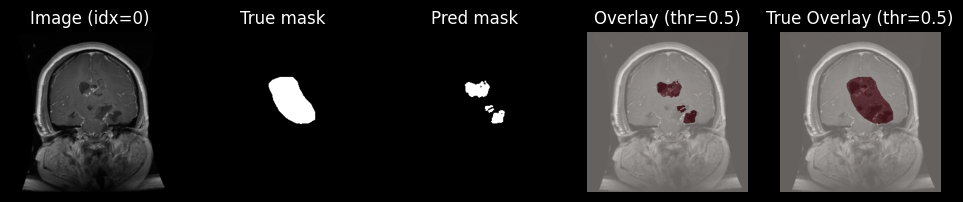

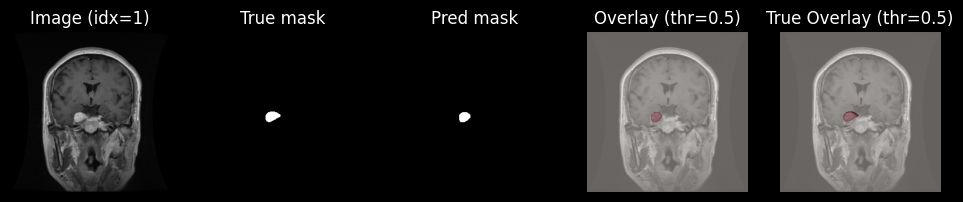

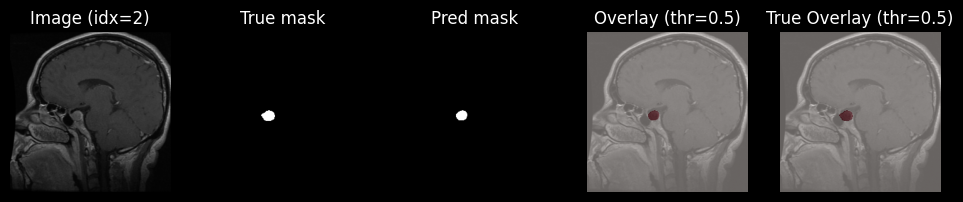

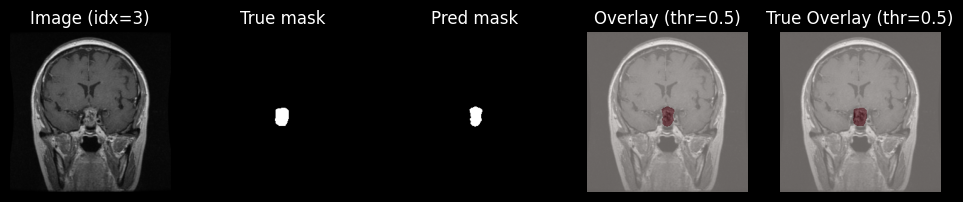

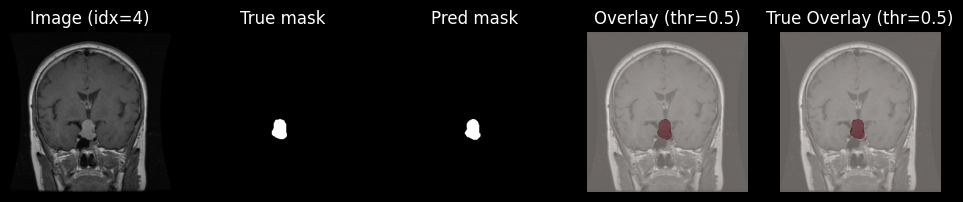

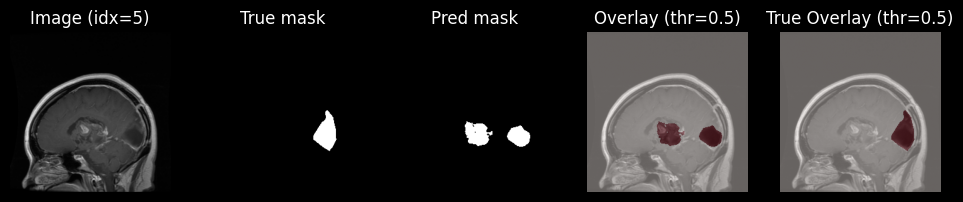

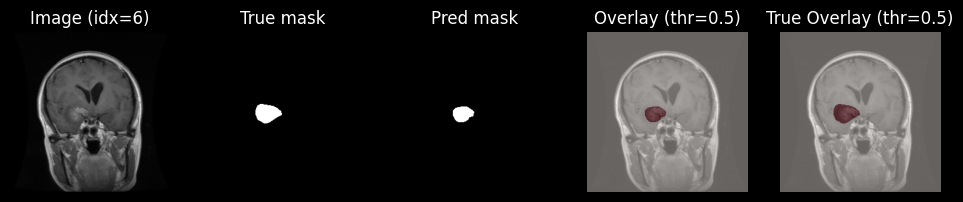

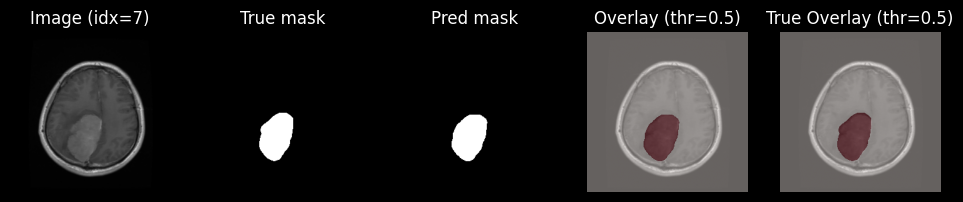

In [30]:
import random

model.eval()

indices = range(len(images))
with torch.no_grad():
    for idx in indices:
        img, true_mask = images[idx],masks[idx]

        img_batch = img.unsqueeze(0).to(device)
        true_mask_batch = true_mask.unsqueeze(0).to(device)

        logits = model(img_batch)

        probs = torch.sigmoid(logits) 

        pred_mask = (probs > 0.5).float()

        img_np = img.permute(1, 2, 0).cpu().numpy() 
        true_np = true_mask.squeeze(0).cpu().numpy()
        pred_np = pred_mask.squeeze(0).squeeze(0).cpu().numpy() 
        prob_np = probs.squeeze(0).squeeze(0).cpu().numpy() 

       
        plt.figure(figsize=(12, 3))

        plt.subplot(1, 5, 1)
        plt.title(f"Image (idx={idx})")
        plt.imshow(img_np)
        plt.axis("off")

        plt.subplot(1, 5, 2)
        plt.title("True mask")
        plt.imshow(true_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 5, 3)
        plt.title("Pred mask")
        plt.imshow(pred_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 5, 4)
        plt.title(f"Overlay (thr={0.5})")
        plt.imshow(img_np)
        plt.imshow(pred_np, alpha=0.4, cmap="Reds")  
        plt.axis("off")

        plt.subplot(1, 5, 5)
        plt.title(f"True Overlay (thr={0.5})")
        plt.imshow(img_np)
        plt.imshow(true_np, alpha=0.4, cmap="Reds") 
        plt.axis("off")

        plt.show()

In [28]:
train_dataloader,val_dataloader=training_preprocessor = SegmentationImageTrainingPreprocessing(
    training_folder_images="/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/images",
    training_folder_masks="/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation/masks",
    folder_path="/kaggle/working/tumerReport",
    binary_mask_threshold=128,
    validation_folder_images=None,
    split_training=True,
    augment=False,
    val_size=0.2,
    batch_size=8,
    random_state=23,
    images_size=(256, 256),
    brightness=False,
    contrast=False
).common_preprocessing()
images,masks=next(iter(train_dataloader))
print(images.shape)
print(masks.shape)


torch.Size([8, 3, 256, 256])
torch.Size([8, 1, 256, 256])


In [31]:
model = UnetModel()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

loss_1 = nn.BCEWithLogitsLoss()
loss_2 = SoftDiceLoss()

In [32]:
epochs = 20
log_interval = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model2 = model.to(device)

best_dice = -1.0

for _e in range(epochs):
    
    model.train()
    
    loss_mean = 0
    lm_count = 0

    for batch_idx, (imgs, masks) in enumerate(train_dataloader):
        
        imgs, masks = imgs.to(device), masks.to(device)
        
        masks = masks.float()

        predict = model(imgs)
        loss = loss_1(predict, masks) + loss_2(predict, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean += loss.item()

        if (batch_idx + 1) % log_interval == 0:
            print(f"Epoch [{_e+1}/{epochs}] | Batch [{batch_idx+1}/{len(train_dataloader)}] | Train loss: {loss_mean / lm_count:.4f}")

    val_loss, val_dice = validate(model, val_dataloader, loss_1, loss_2, device)

    print(f"Epoch {_e+1}: " f"val_loss = {val_loss:.4f}, val_dice = {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(
            {
                "epoch": _e + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_dice": best_dice,
            },
            "best_model.tar",
        )
        
        print(f"best model saved (dice = {best_dice:.4f})")

Epoch [1/20] | Batch [100/307] | Train loss: 1.5256
Epoch [1/20] | Batch [200/307] | Train loss: 1.3165
Epoch [1/20] | Batch [300/307] | Train loss: 1.1586
Epoch 1: val_loss = 1.0087, val_dice = 0.1147
best model saved (dice = 0.1147)
Epoch [2/20] | Batch [100/307] | Train loss: 0.7145
Epoch [2/20] | Batch [200/307] | Train loss: 0.6926
Epoch [2/20] | Batch [300/307] | Train loss: 0.6755
Epoch 2: val_loss = 0.6396, val_dice = 0.4362
best model saved (dice = 0.4362)
Epoch [3/20] | Batch [100/307] | Train loss: 0.5836
Epoch [3/20] | Batch [200/307] | Train loss: 0.5815
Epoch [3/20] | Batch [300/307] | Train loss: 0.5846
Epoch 3: val_loss = 0.6470, val_dice = 0.4879
best model saved (dice = 0.4879)
Epoch [4/20] | Batch [100/307] | Train loss: 0.5688
Epoch [4/20] | Batch [200/307] | Train loss: 0.5609
Epoch [4/20] | Batch [300/307] | Train loss: 0.5488
Epoch 4: val_loss = 0.5662, val_dice = 0.5222
best model saved (dice = 0.5222)
Epoch [5/20] | Batch [100/307] | Train loss: 0.5271
Epoch [5

In [33]:
chekpoint = torch.load('best_model.tar',map_location=device)
model.load_state_dict(chekpoint["model_state"])

model.to(device)
model.eval()

print("Loaded epoch:", chekpoint.get("epoch"), "best_dice:", chekpoint.get("best_dice"))

Loaded epoch: 19 best_dice: 0.7639413870774306


In [34]:
images,masks=next(iter(val_dataloader))


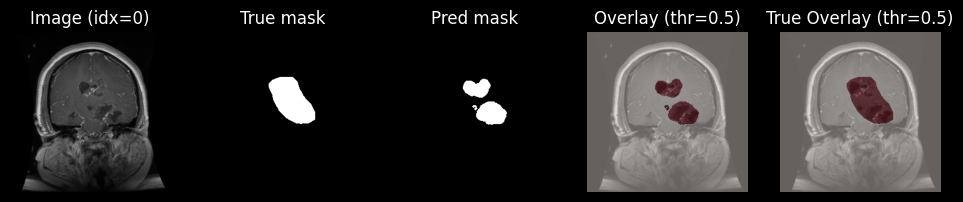

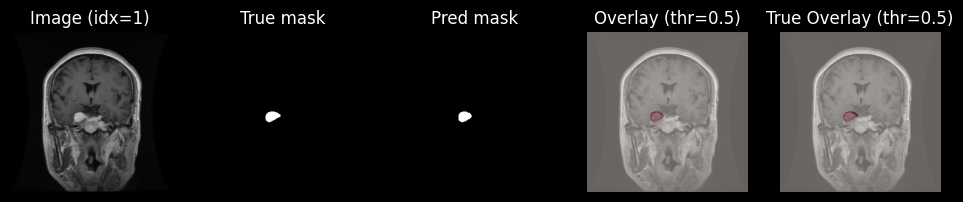

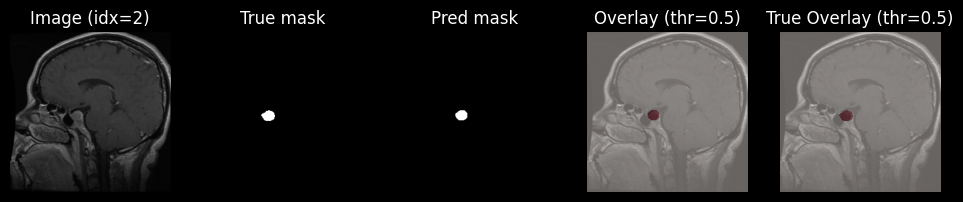

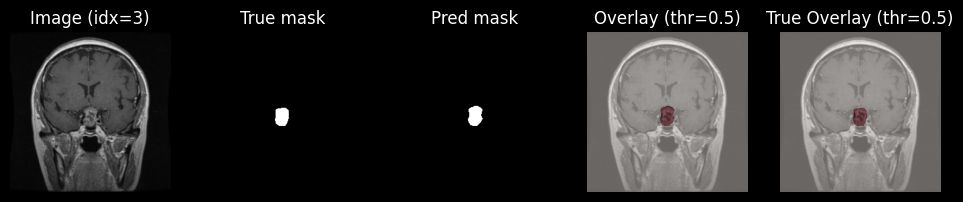

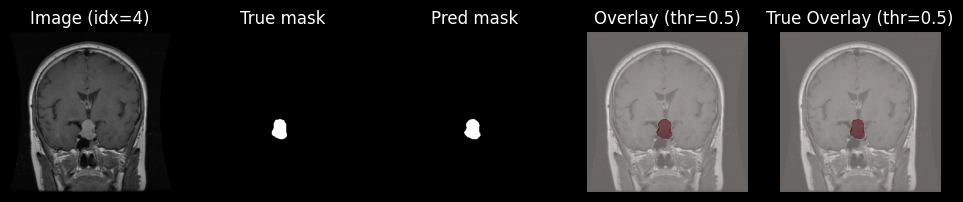

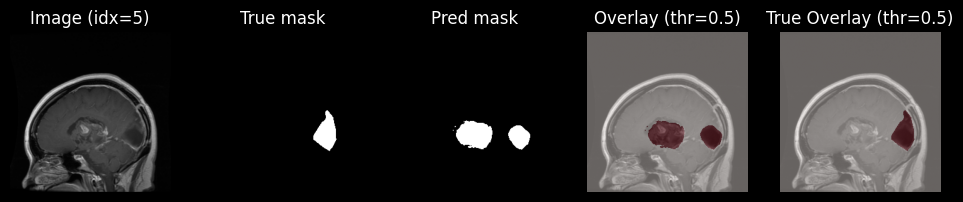

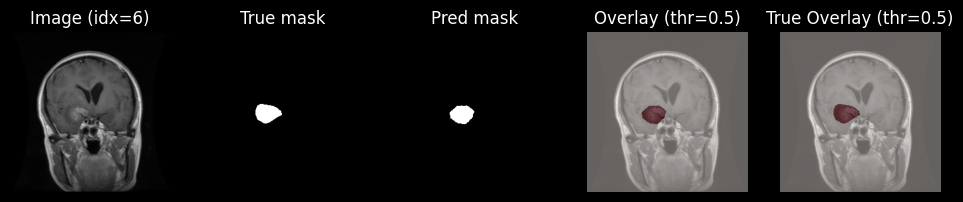

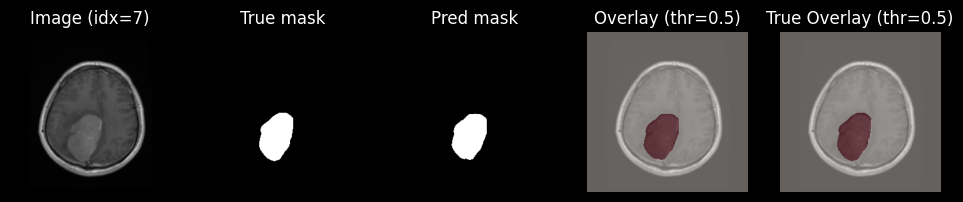

In [35]:
import random

model.eval()

indices = range(len(images))
with torch.no_grad():
    for idx in indices:
        img, true_mask = images[idx],masks[idx]

        img_batch = img.unsqueeze(0).to(device)
        true_mask_batch = true_mask.unsqueeze(0).to(device)

        logits = model(img_batch)

        probs = torch.sigmoid(logits) 

        pred_mask = (probs > 0.5).float()

        img_np = img.permute(1, 2, 0).cpu().numpy() 
        true_np = true_mask.squeeze(0).cpu().numpy()
        pred_np = pred_mask.squeeze(0).squeeze(0).cpu().numpy() 
        prob_np = probs.squeeze(0).squeeze(0).cpu().numpy() 

       
        plt.figure(figsize=(12, 3))

        plt.subplot(1, 5, 1)
        plt.title(f"Image (idx={idx})")
        plt.imshow(img_np)
        plt.axis("off")

        plt.subplot(1, 5, 2)
        plt.title("True mask")
        plt.imshow(true_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 5, 3)
        plt.title("Pred mask")
        plt.imshow(pred_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 5, 4)
        plt.title(f"Overlay (thr={0.5})")
        plt.imshow(img_np)
        plt.imshow(pred_np, alpha=0.4, cmap="Reds")  
        plt.axis("off")

        plt.subplot(1, 5, 5)
        plt.title(f"True Overlay (thr={0.5})")
        plt.imshow(img_np)
        plt.imshow(true_np, alpha=0.4, cmap="Reds") 
        plt.axis("off")

        plt.show()